<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Classification Metrics

---

### About
An introduction to Classification Metrics.


### Learning Objectives
- Create a confusion matrix.
- Calculate common classification metrics from the confusion matrix.


### Notebook Guide

- Imports
- Load Data Set and EDA
- Now You Try
- Confusion Matrix
- Calculate Classification Metrics
   - Accuracy
   - Recall / Sensitivity
   - Precision
   - Specificity / True Negative Rate (TNR)
   - $F_1$ score
- How can we optimise our model?

# Imports

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

%matplotlib inline

# Load Data Set and EDA

Built-in `scikit-learn` datasets come in their own special format. You can study this on your own but it's not that interesting.

In [3]:
data = load_breast_cancer()
X = data.data
y = 1 - data.target

In [4]:
# Inspect the data dictionary

# Each row represents one breast mass: a localized swelling or area of thickened tissue 
# that feels different from the surrounding breast tissue examined using a fine-needle aspirate (FNA), 
# with the features describing measurements of cell nuclei taken from that sample.

# Target
# benign — non-cancerous (0)
# malignant — cancerous (1)

print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [5]:
bc = pd.DataFrame(X, columns=data.feature_names)
bc['cancer'] = y
bc.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,cancer
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


In [6]:
bc.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

Since we are learning about classification metrics, we will not conduct extensive EDA in this notebook.  This is a clean data set so we can model it straight away.

# Now You Try

## Model

Using random state of 99, create a train test split, standard scale the data, and carry out a 5-nearest neighbors model (knn).

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=99, stratify=y)

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

knn = KNeighborsClassifier()
knn.fit(X_train_sc, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## Make Predictions

Create `y_pred`, our vector of predictions.

In [8]:
y_pred = knn.predict(X_test_sc)

# Confusion Matrix

Let's create a confusion matrix using the `confusion_matrix` function from `sklearn`'s `metrics` module.

In [9]:
cm = confusion_matrix(y_true= y_test, y_pred= y_pred)
cm

array([[90,  0],
       [ 3, 50]])

### There is a way to visualise the confusion matrix better:

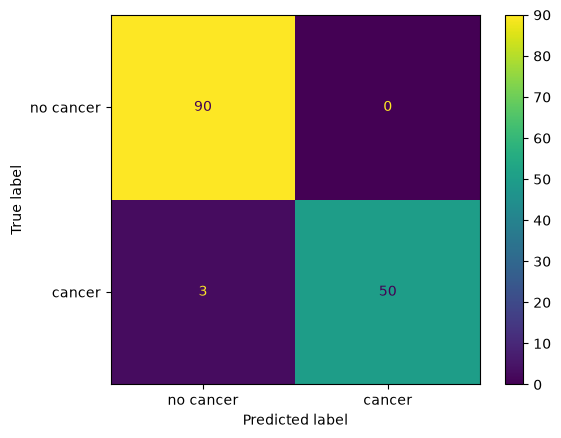

In [10]:
# You can  plot the data more readibly using ConfusionMatrixDisplay

class_names = []

ConfusionMatrixDisplay(confusion_matrix= cm,
                       display_labels= ['no cancer', 'cancer']
                       ).plot()

# Calculate Classification Metrics

Although we are calculating these metrics by hand here, you can implement them all in `scikit-learn` by going to the [metrics page](https://scikit-learn.org/0.15/modules/classes.html#module-sklearn.metrics).

## Accuracy

Overall, how often is the classifier correct?

In this case, how many cases were correctly diagnosed as either being benign or being malignant?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n = 143</td>
    <td style=""><b>Predicted: Benign (0)</b></td>
    <td style=""><b>Predicted: Malignant (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Benign (0)</b></td>
    <td style="text-align: center; background-color: red">TN = 98</td>
    <td style="text-align: center">FP = 1</td>
    <td style="text-align: center">99</td>
</tr>
<tr>
    <td><b>Actual: Malignant (1)</b></td>
    <td style="text-align: center">FN = 2</td>
    <td style="text-align: center; background-color: green">TP = 42</td>
    <td style="text-align: center">44</td>
</tr>
<tr style="border: none">
    <td style="border: none"></td>
    <td style="text-align: center">100</td>
    <td style="text-align: center">41</td>
</tr>

</table>

<br />

$$\boldsymbol{\textbf{Accuracy} = \frac{{\textbf{\color{DarkGreen} TP}} + {\textbf{\color{Red} TN}}}{\textbf{\color{Blue} Total}} = \frac{{\color{DarkGreen} 42} + {\color{Red} 98}}{\color{Blue} 143} = 0.98}$$

## Recall / Sensitivity / True Positive Rate (TPR)

Among all actual cases of the target class, what proportion did we detect?

In this case, of all cases which were actually malignant, what proportion were predicted (in the test set)?


<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n = 143</td>
    <td style=""><b>Predicted: Benign (0)</b></td>
    <td style=""><b>Predicted: Malignant (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Benign (0)</b></td>
    <td style="text-align: center">TN = 98</td>
    <td style="text-align: center">FP = 1</td>
    <td style="text-align: center">99</td>
</tr>
<tr>
    <td><b>Actual: Malignant (1)</b></td>
    <td style="text-align: center; background-color: orchid">FN = 2</td>
    <td style="text-align: center; background-color: green">TP = 42</td>
    <td style="text-align: center">44</td>
</tr>
<tr style="border: none">
    <td style="border: none"></td>
    <td style="text-align: center">100</td>
    <td style="text-align: center">41</td>
</tr>

</table>

<br />

$$\boldsymbol{\textbf{Recall} = \textbf{Sensitivity} = \textbf{True Positive Rate (TPR)} = \frac{\textbf{\color{DarkGreen} TP}}{{\textbf{\color{DarkGreen} TP}} + {\textbf{\color{Orchid} FN}}} = \frac{{\color{DarkGreen} 42}}{{\color{DarkGreen} 42} + {\color{Orchid} 2}} = 0.95}$$

## Precision
Among all that were predicted to be the target class, what proportion were correct?

In this case, among those who were predicted to have a malignant case, what proportion were correctly forecast (in the test set)?

<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n = 143</td>
    <td style=""><b>Predicted: Benign (0)</b></td>
    <td style=""><b>Predicted: Malignant (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Benign (0)</b></td>
    <td style="text-align: center">TN = 98</td>
    <td style="text-align: center;background-color: orange">FP = 1</td>
    <td style="text-align: center">99</td>
</tr>
<tr>
    <td><b>Actual: Malignant (1)</b></td>
    <td style="text-align: center">FN = 2</td>
    <td style="text-align: center; background-color: green">TP = 42</td>
    <td style="text-align: center">44</td>
</tr>
<tr style="border: none">
    <td style="border: none"></td>
    <td style="text-align: center">100</td>
    <td style="text-align: center">41</td>
</tr>

</table>


<br />

$$\boldsymbol{\textbf{Precision} = \frac{\textbf{\color{DarkGreen} TP}}{{\textbf{\color{DarkGreen} TP}} + {\textbf{\color{Orange} FP}}} = \frac{{\color{DarkGreen} 42}}{{\color{DarkGreen} 42} + {\color{Orange} 1}} = 0.98}$$

## Specificity / True Negative Rate (TNR)
Among all actual cases that were not in the target class, what proportion did we detect?

In this case, among all those who had a benign case, what proportion were correctly detected (in the test set)?


<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n = 143</td>
    <td style=""><b>Predicted: Benign (0)</b></td>
    <td style=""><b>Predicted: Malignant (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Benign (0)</b></td>
    <td style="text-align: center; background-color: red">TN = 98</td>
    <td style="text-align: center; background-color: orange">FP = 1</td>
    <td style="text-align: center">99</td>
</tr>
<tr>
    <td><b>Actual: Malignant (1)</b></td>
    <td style="text-align: center">FN = 2</td>
    <td style="text-align: center">TP = 42</td>
    <td style="text-align: center">44</td>
</tr>
<tr style="border: none">
    <td style="border: none"></td>
    <td style="text-align: center">100</td>
    <td style="text-align: center">41</td>
</tr>

</table>

<br />

$$\boldsymbol{\textbf{Specificity} = \textbf{True Negative Rate (TNR)} = \frac{\textbf{\color{Red} TN}}{{\textbf{\color{Red} TN}} + {\textbf{\color{Orange} FP}}} = \frac{{\color{Red} 98}}{{\color{Red} 98} + {\color{Orange} 1}} = 0.99}$$

## $F_1$ Score
F1 measures the balance between correctly identifying malignant cases and avoiding false malignant predictions.


<table style="border: none">
<tr style="border: none">
    <td style="border: none; vertical-align: bottom; color: blue">n = 143</td>
    <td style=""><b>Predicted: Benign (0)</b></td>
    <td style=""><b>Predicted: Malignant (1)</b></td>
</tr>
<tr>
    <td><b>Actual: Benign (0)</b></td>
    <td style="text-align: center">TN = 98</td>
    <td style="text-align: center; background-color: orange">FP = 1</td>
    <td style="text-align: center">99</td>
</tr>
<tr>
    <td><b>Actual: Malignant (1)</b></td>
    <td style="text-align: center; background-color: orchid">FN = 2</td>
    <td style="text-align: center; background-color: green">TP = 42</td>
    <td style="text-align: center">44</td>
</tr>
<tr style="border: none">
    <td style="border: none"></td>
    <td style="text-align: center">100</td>
    <td style="text-align: center">41</td>
</tr>

</table>

<br />

$$\boldsymbol{F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{2 \cdot \textbf{\color{DarkGreen} TP}}{\left (2 \cdot \textbf{\color{DarkGreen} TP} \right ) + \textbf{\color{Orange} FP} + \textbf{\color{Orchid} FN}} = \frac{2 \cdot \textbf{\color{DarkGreen} 42}}{\left (2 \cdot \textbf{\color{DarkGreen} 42} \right ) + \textbf{\color{Orange} 1} + \textbf{\color{Orchid} 2}} = 0.97}$$

In [11]:
# Using scikit-learn for these metrics...

# Accuracy
print(f'Accuracy: {accuracy_score(y_true= y_test, y_pred= y_pred)}')

# Recall / Sensitivity / True Positive Rate (TPR)
print(f'Recall / Sensitivity / True Positive Rate (TPR): {recall_score(y_test, y_pred)}')

# Precision
print(f'Precision: {precision_score(y_test, y_pred)}')

# Specificity / True Negative Rate (TNR) is not defined in scikit-learn

# F1 score
print(f'F1 score: {f1_score(y_test, y_pred)}')

Accuracy: 0.9790209790209791
Recall / Sensitivity / True Positive Rate (TPR): 0.9433962264150944
Precision: 1.0
F1 score: 0.970873786407767


# How can we optimise our model?

We want to minimime the False Negatives in our model, even if it means a few more False Positives, to ensure that all actually malign cases are identified as soon as possible.

### What metric should we optimise for our model?

<details>
<summary></summary>
Recall / Sensitivity, since reducing the number of FNs will increase this score.  We want this to be as close to 1 as possible.

We can increase recall by lowering the threshold for predicting survival.
</details>

In [12]:
# Extract the predicted probabilities for the test set 

y_pred_prob = knn.predict_proba(X_test_sc)[:,1] # to return the success prob (the patient has cancer)
y_pred_prob

array([1. , 0. , 0. , 0.8, 1. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ,
       0. , 1. , 0.4, 0. , 0. , 1. , 1. , 0. , 0. , 1. , 0. , 0. , 0. ,
       0. , 1. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 1. , 1. , 0. , 1. ,
       0. , 0.2, 1. , 0. , 1. , 1. , 0. , 1. , 0. , 1. , 1. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 1. , 0.2, 0. , 0. , 0. , 0. , 1. , 1. ,
       0. , 0. , 0.8, 1. , 1. , 1. , 1. , 1. , 0. , 1. , 0. , 0. , 0. ,
       0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 1. , 0. , 0. , 0. ,
       0. , 1. , 1. , 0.4, 1. , 0. , 0. , 0. , 1. , 0. , 0. , 1. , 0. ,
       1. , 1. , 0. , 0.2, 0.6, 0. , 0. , 0. , 0. , 1. , 0. , 0.8, 1. ,
       1. , 0. , 1. , 1. , 0. , 0. , 0. , 1. , 0. , 1. , 0. , 0. , 0. ,
       1. , 1. , 0. , 0. , 0. , 1. , 0. , 0. , 0. , 0. , 1. , 0.2, 1. ])

In [13]:
# Reduce the probability threshold to 10% i.e. if there is a 10% or probability that a case may be malignant,
# label it as such (the default is 50%).

y_pred_class = np.where(y_pred_prob >= 0.1, 1, 0) #(condition, true_return, false_return)
y_pred_class

array([1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1])

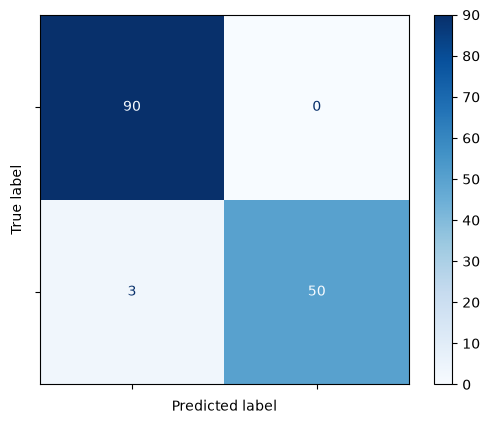

In [14]:
# Look at the confusion matrix before changing the probability threshold...

ConfusionMatrixDisplay(
                        confusion_matrix=cm,
                        display_labels=class_names
                      ).plot(cmap=plt.cm.Blues);

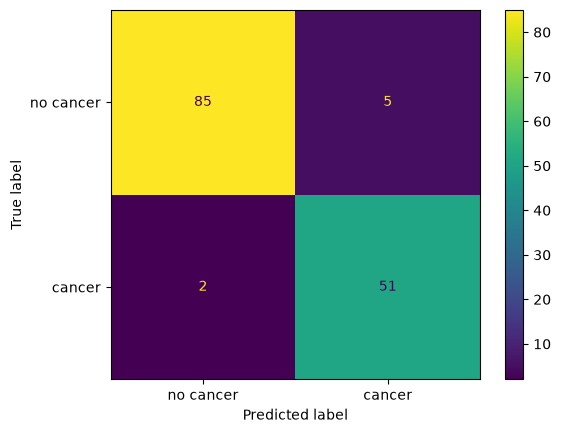

In [15]:
# ...and compare it with the confusion matrix for the classification with a lower threshold

cm_new = confusion_matrix(y_test, y_pred_class)

ConfusionMatrixDisplay(
                        confusion_matrix=cm_new,
                        display_labels=['no cancer', 'cancer']
                      ).plot();

Let's see how the change affects the classification metrics.

In [16]:
# Classification metrics - OLD 
print(f'Accuracy: {accuracy_score(y_test, y_pred)}')

# Recall / Sensitivity / True Positive Rate (TPR)
print(f'Recall / Sensitivity / True Positive Rate (TPR): {recall_score(y_test, y_pred)}')

# Precision
print(f'Precision: {precision_score(y_test, y_pred)}')

# Specificity / True Negative Rate (TNR)
print(f'Specificity: {98/(98+1)}')

# F1 score
print(f'F1 score: {f1_score(y_test, y_pred)}')

Accuracy: 0.9790209790209791
Recall / Sensitivity / True Positive Rate (TPR): 0.9433962264150944
Precision: 1.0
Specificity: 0.98989898989899
F1 score: 0.970873786407767


In [17]:
# Classification metrics - NEW
print(f'Accuracy: {accuracy_score(y_test, y_pred_class)}')

# Recall / Sensitivity / True Positive Rate (TPR)
print(f'Recall / Sensitivity / True Positive Rate (TPR): {recall_score(y_test, y_pred_class)}')

# Precision
print(f'Precision: {precision_score(y_test, y_pred_class)}')

# Specificity / True Negative Rate (TNR)
print(f'Specificity: {88/(88+11)}')

# F1 score
print(f'F1 score: {f1_score(y_test, y_pred_class)}')

Accuracy: 0.951048951048951
Recall / Sensitivity / True Positive Rate (TPR): 0.9622641509433962
Precision: 0.9107142857142857
Specificity: 0.8888888888888888
F1 score: 0.9357798165137615


## What does this mean?

Recall has increased.  All the other metrics have worsened considerably, which is the trade off we are making.  Allowing many more False Positives will increase anxiety for a lot of people, and the medical costs will increase, but more lives may well be saved.